# Feature Matrix Tour

In this notebook I inspect the frozen transition-model feature matrices. Each row corresponds to one candidate plan, and each column is a transition-consistency statistic computed from a frozen source model.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

DATASET = ROOT / "data" / "validity_dataset"
CANDIDATES = DATASET / "candidates"
FEATURES = DATASET / "features"
HEADS = ROOT / "models" / "validity_heads"
RESULTS = ROOT / "results" / "analysis"

print(f"Repository root: {ROOT}")

Repository root: C:\Users\visha\OneDrive\Desktop\tokenizer-paper-workspace\planfm-validity


In [2]:
family = "dd_xgb_wl_delta"
seed = 13
split = "train"
path = FEATURES / family / f"seed_{seed}" / f"{split}.npz"
feature_file = np.load(path, allow_pickle=True)

X = feature_file["X"]
y = feature_file["y"]
feature_names = [str(name) for name in feature_file["feature_names"]]

print(f"Loaded: {path.relative_to(ROOT)}")
print(f"X shape: {X.shape}")
print(f"labels: {np.bincount(y)} as [invalid, valid]")
print(f"number of feature names: {len(feature_names)}")
feature_names[:12]

Loaded: data\validity_dataset\features\dd_xgb_wl_delta\seed_13\train.npz
X shape: (1156, 55)
labels: [925 231] as [invalid, valid]
number of feature names: 55


['residual_l2_mean',
 'residual_l2_std',
 'residual_l2_min',
 'residual_l2_max',
 'residual_l2_final',
 'residual_l1_mean_mean',
 'residual_l1_mean_std',
 'residual_l1_mean_min',
 'residual_l1_mean_max',
 'residual_l1_mean_final',
 'cosine_distance_mean',
 'cosine_distance_std']

In [3]:
metadata = pd.DataFrame({
    "candidate_id": feature_file["candidate_ids"].astype(str),
    "domain": feature_file["domains"].astype(str),
    "split": feature_file["splits"].astype(str),
    "problem": feature_file["problems"].astype(str),
    "corruption_type": feature_file["corruption_types"].astype(str),
    "label_valid": y,
})
metadata.head()

,candidate_id,domain,split,problem,corruption_type,label_valid
0,blocks::train::probBLOCKS-4-0::000::gold,blocks,train,probBLOCKS-4-0,gold,1
1,blocks::train::probBLOCKS-4-0::001::truncate,blocks,train,probBLOCKS-4-0,truncate,0
2,blocks::train::probBLOCKS-4-0::002::delete,blocks,train,probBLOCKS-4-0,delete,0
3,blocks::train::probBLOCKS-4-0::003::swap,blocks,train,probBLOCKS-4-0,swap,0
4,blocks::train::probBLOCKS-4-0::004::replace,blocks,train,probBLOCKS-4-0,replace,0


In [4]:
features_df = pd.DataFrame(X, columns=feature_names)
means = features_df.assign(label_valid=y).groupby("label_valid").mean().T
means.columns = ["invalid_mean", "valid_mean"]
means["abs_difference"] = (means["valid_mean"] - means["invalid_mean"]).abs()
means.sort_values("abs_difference", ascending=False).head(12)

,invalid_mean,valid_mean,abs_difference
final_minus_initial_goal_l2,-8.188428,-16.599421,8.410993
final_goal_l2,10.225207,1.834142,8.391066
current_goal_l2_final,10.311415,2.823468,7.487947
current_goal_l2_min,10.288202,2.823468,7.464735
pred_goal_l2_final,8.794479,2.296706,6.497773
pred_goal_l2_min,8.761475,2.296706,6.464768
current_goal_l2_mean,13.399093,10.689445,2.709648
pred_goal_l2_mean,11.778810,9.177933,2.600877
pred_norm_final,15.293134,17.827654,2.534520
current_goal_l2_std,2.606333,4.942583,2.336250


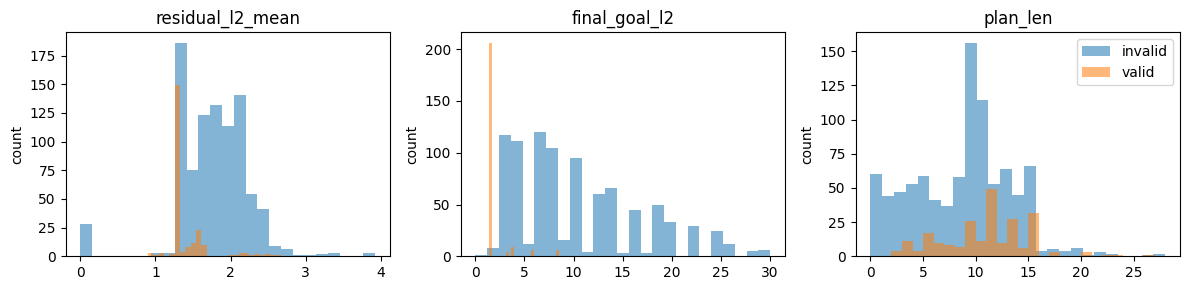

In [5]:
import matplotlib.pyplot as plt

plot_df = features_df[["residual_l2_mean", "final_goal_l2", "plan_len"]].copy()
plot_df["label_valid"] = np.where(y == 1, "valid", "invalid")

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, col in zip(axes, ["residual_l2_mean", "final_goal_l2", "plan_len"]):
    for label, group in plot_df.groupby("label_valid"):
        ax.hist(group[col], bins=25, alpha=0.55, label=label)
    ax.set_title(col)
    ax.set_ylabel("count")
axes[-1].legend()
plt.tight_layout()
plt.show()

In [6]:
# The feature matrices are available for every source family, seed, and split.
available = []
for family_dir in sorted(FEATURES.iterdir()):
    if not family_dir.is_dir():
        continue
    for seed_dir in sorted(family_dir.iterdir()):
        if not seed_dir.is_dir():
            continue
        available.append({
            "family": family_dir.name,
            "seed": seed_dir.name.replace("seed_", ""),
            "splits": ", ".join(sorted(p.stem for p in seed_dir.glob("*.npz"))),
        })
pd.DataFrame(available).head(12)

,family,seed,splits
0,ad_lstm_wl_delta,13,"test-extrapolation, test-interpolation, train,..."
1,ad_lstm_wl_delta,23,"test-extrapolation, test-interpolation, train,..."
2,ad_lstm_wl_delta,37,"test-extrapolation, test-interpolation, train,..."
3,ad_xgb_wl_delta,13,"test-extrapolation, test-interpolation, train,..."
4,ad_xgb_wl_delta,23,"test-extrapolation, test-interpolation, train,..."
5,ad_xgb_wl_delta,37,"test-extrapolation, test-interpolation, train,..."
6,dd_lstm_shortest_path_delta,13,"test-extrapolation, test-interpolation, train,..."
7,dd_lstm_shortest_path_delta,23,"test-extrapolation, test-interpolation, train,..."
8,dd_lstm_shortest_path_delta,37,"test-extrapolation, test-interpolation, train,..."
9,dd_xgb_wl_delta,13,"test-extrapolation, test-interpolation, train,..."
